accuracy: 0.970
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


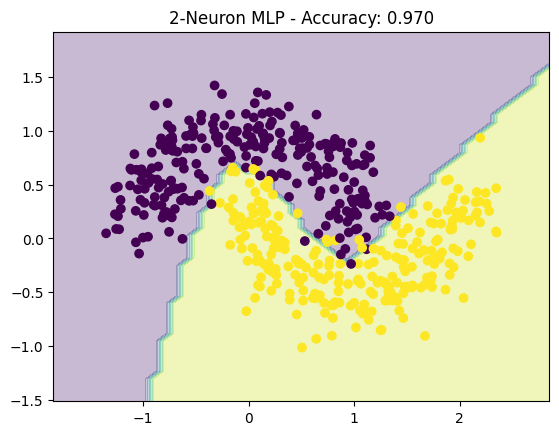

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

#creat data and modle
x,y = make_moons(500, noise = 0.2)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation = 'relu', input_shape = (2,)),#relu = activation function for none linear , sigmoid = activation function for linear
    tf.keras.layers.Dense(32, activation = 'relu'),
    tf.keras.layers.Dense(16, activation = 'relu'),
    tf.keras.layers.Dense(2, activation = 'softmax') #softmax = activation function
])

#train
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
model.fit(x, y, epochs = 50, verbose = 0)

#show results
accuracy = model.evaluate(x, y, verbose = 0)[1]
print(f"accuracy: {accuracy:.3f}")

#plot
x_min, x_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
y_min, y_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))
z = np.argmax(model.predict(np.c_[xx.ravel(), yy.ravel()]), axis = 1).reshape(xx.shape)
plt.contourf(xx, yy, z, alpha = 0.3)
plt.scatter(x[:, 0], x[:, 1], c = y)
plt.title(f"2-Neuron MLP - Accuracy: {accuracy:.3f}")
plt.show()